# Breast Cancer Classification — Machine Learning with scikit-learn

**Author:** Taimoor Asad (Python & ML Developer)

## Objective
Build and compare three classification models to predict whether a 
tumor is malignant or benign based on cell nucleus measurements.

## Dataset
- Source: Wisconsin Breast Cancer Dataset (built into scikit-learn)
- Samples: 569 tumors (357 benign, 212 malignant)
- Features: 30 numeric measurements of cell nuclei
- Target: Malignant (0) or Benign (1)

## Models Compared
- Logistic Regression (baseline)
- Random Forest (ensemble)
- Support Vector Machine (SVM)

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['diagnosis'].value_counts())
print("\nFirst 5 rows:")
df.head()

Shape: (569, 32)

Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


## Visualizations

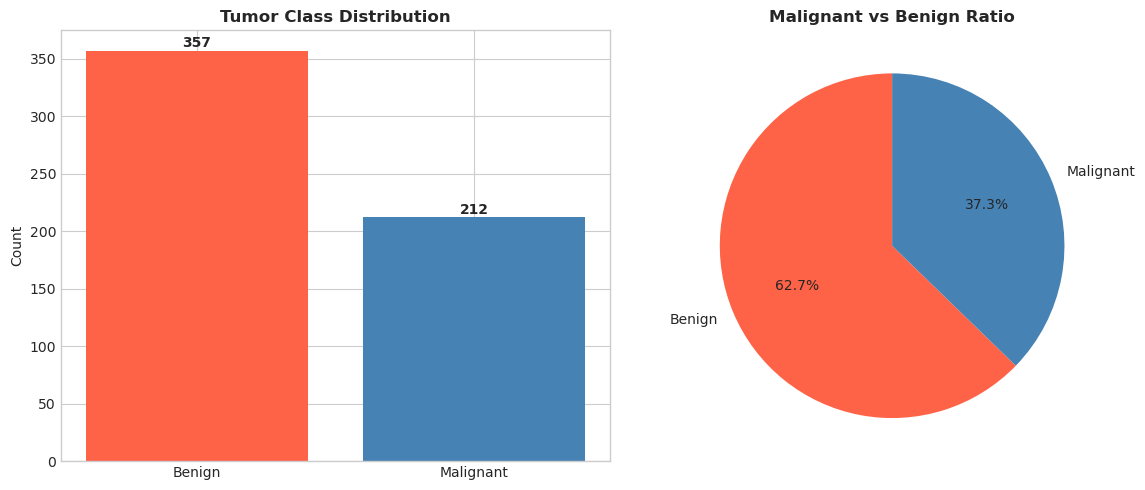

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['diagnosis'].value_counts()
colors = ['tomato', 'steelblue']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Tumor Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 3, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Malignant vs Benign Ratio', fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()

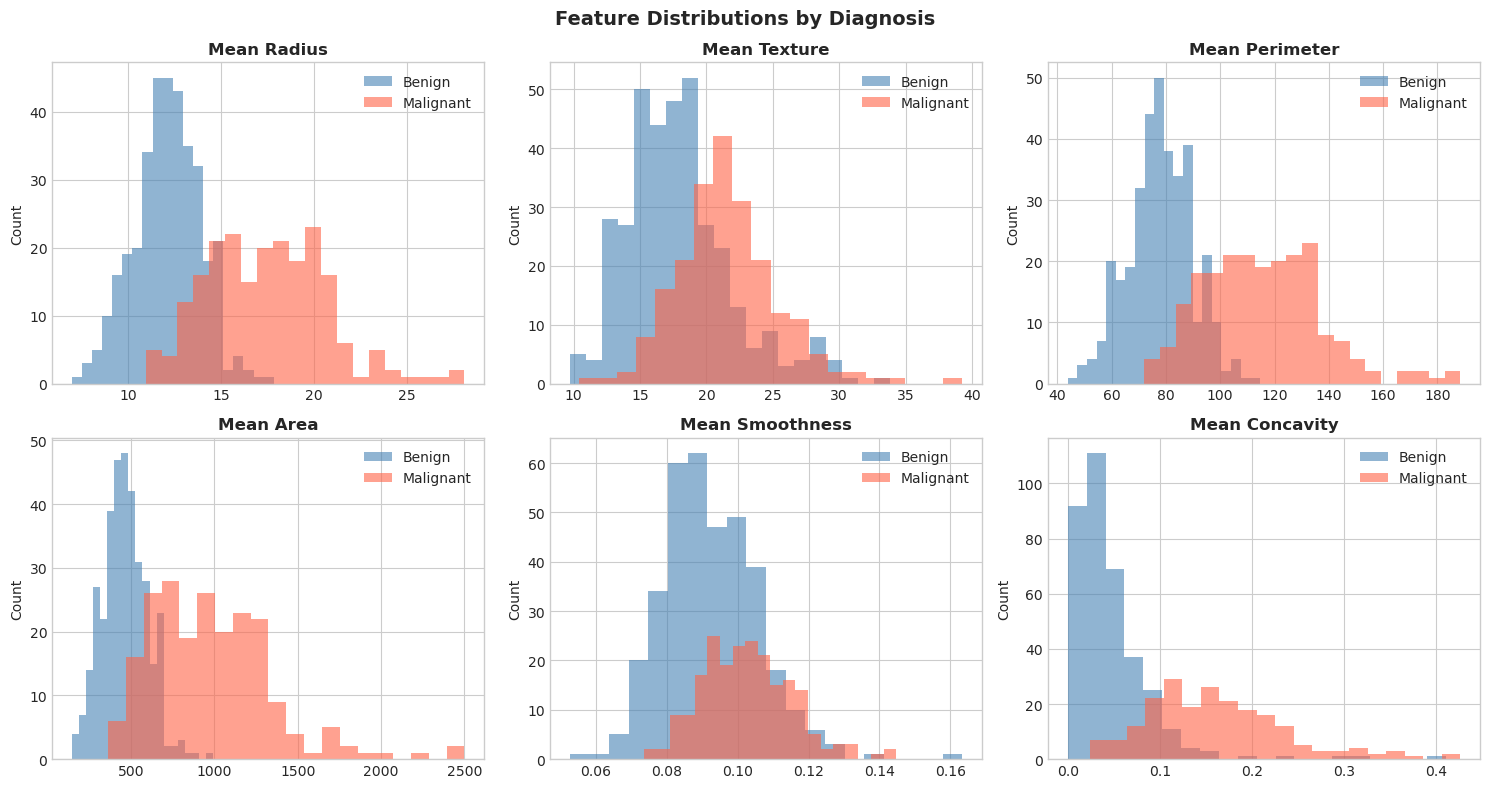

In [4]:
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for diagnosis, color in zip(['Benign', 'Malignant'], ['steelblue', 'tomato']):
        subset = df[df['diagnosis'] == diagnosis][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=diagnosis)
    axes[i].set_title(feat.title(), fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions by Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_feature_distributions.png', dpi=150)
plt.show()

In [5]:
# Features and target
X = df.drop(['target', 'diagnosis'], axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'model': model,
        'preds': preds,
        'proba': proba,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }

print("All models trained successfully.")

All models trained successfully.


In [6]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': f"{res['accuracy']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall': f"{res['recall']:.4f}",
        'F1 Score': f"{res['f1']:.4f}"
    }
    for name, res in results.items()
}).T

print("=== Model Comparison ===")
print(comparison.to_string())

=== Model Comparison ===
                    Accuracy Precision  Recall F1 Score
Logistic Regression   0.9825    0.9861  0.9861   0.9861
Random Forest         0.9561    0.9589  0.9722   0.9655
SVM                   0.9825    0.9861  0.9861   0.9861


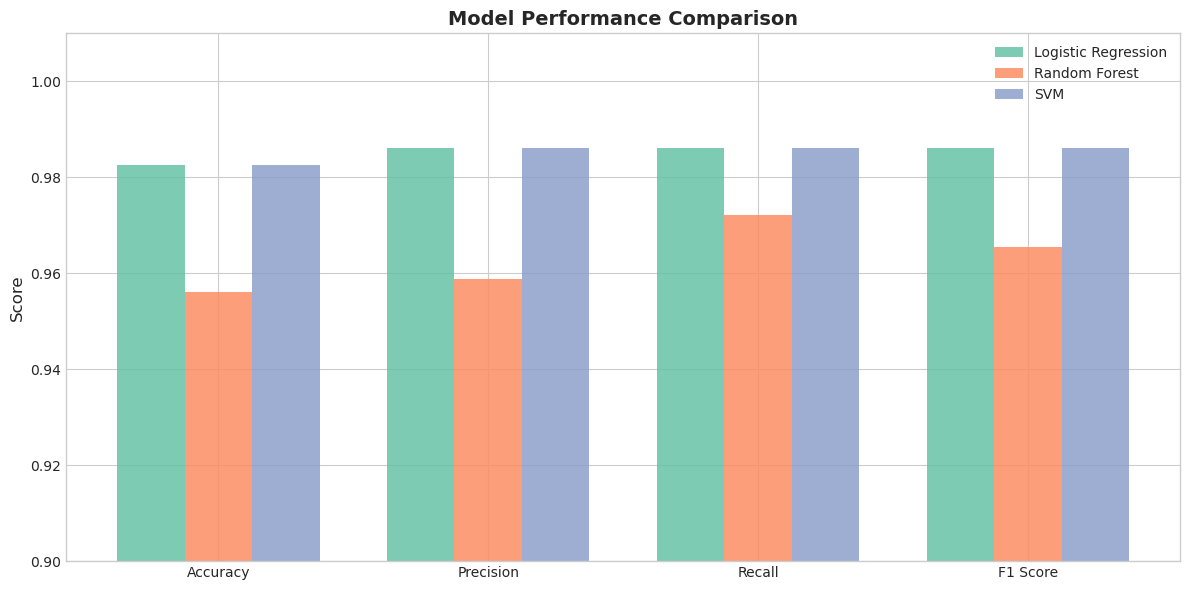

In [7]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = list(results.keys())

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.25

for i, name in enumerate(model_names):
    vals = [results[name]['accuracy'], results[name]['precision'],
            results[name]['recall'], results[name]['f1']]
    bars = ax.bar(x + i*width, vals, width, label=name, alpha=0.85)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.9, 1.01)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.savefig('plot3_model_comparison.png', dpi=150)
plt.show()

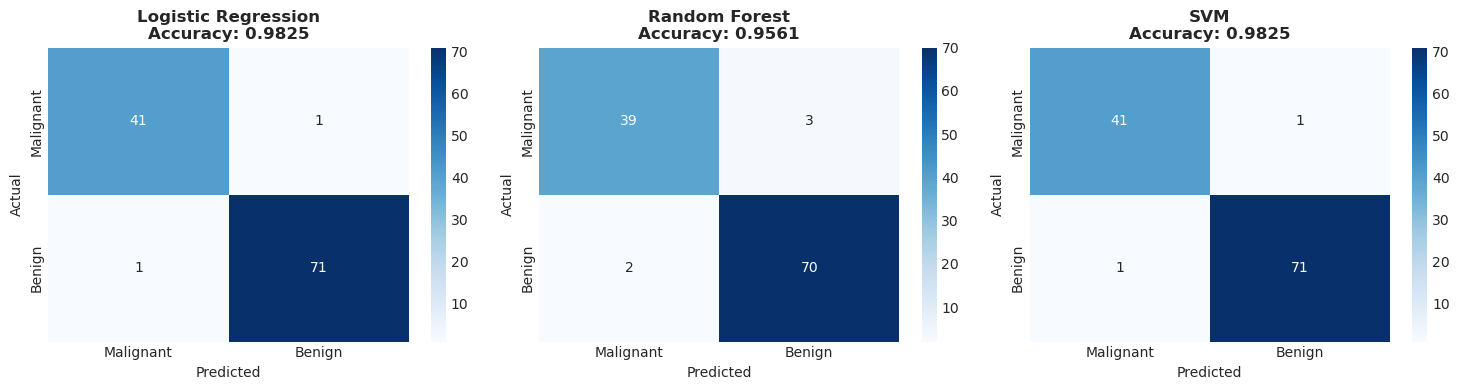

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'],
                ax=ax)
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.4f}',
                 fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('plot4_confusion_matrices.png', dpi=150)
plt.show()

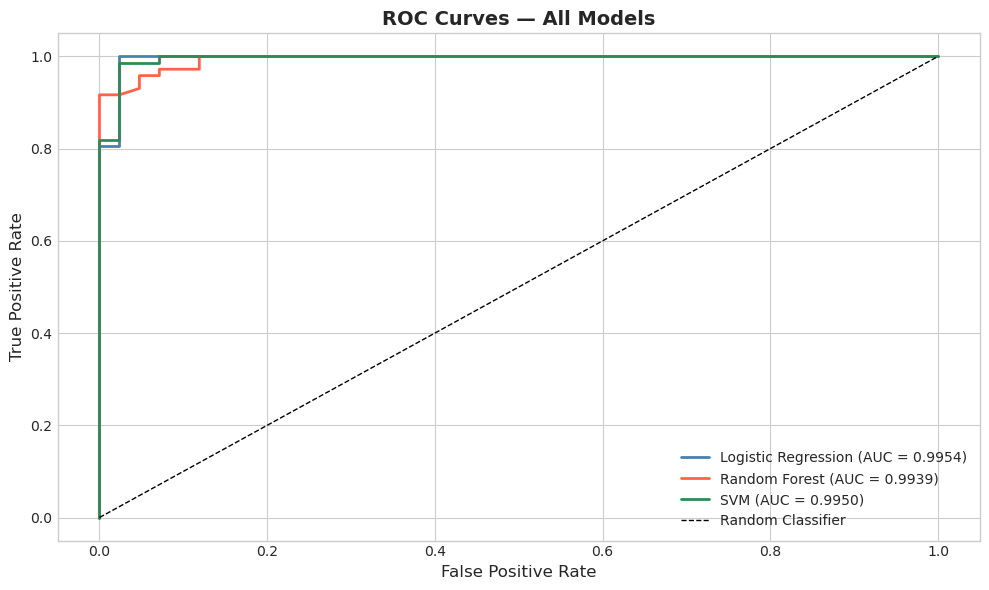

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue', 'tomato', 'seagreen']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plot5_roc_curves.png', dpi=150)
plt.show()

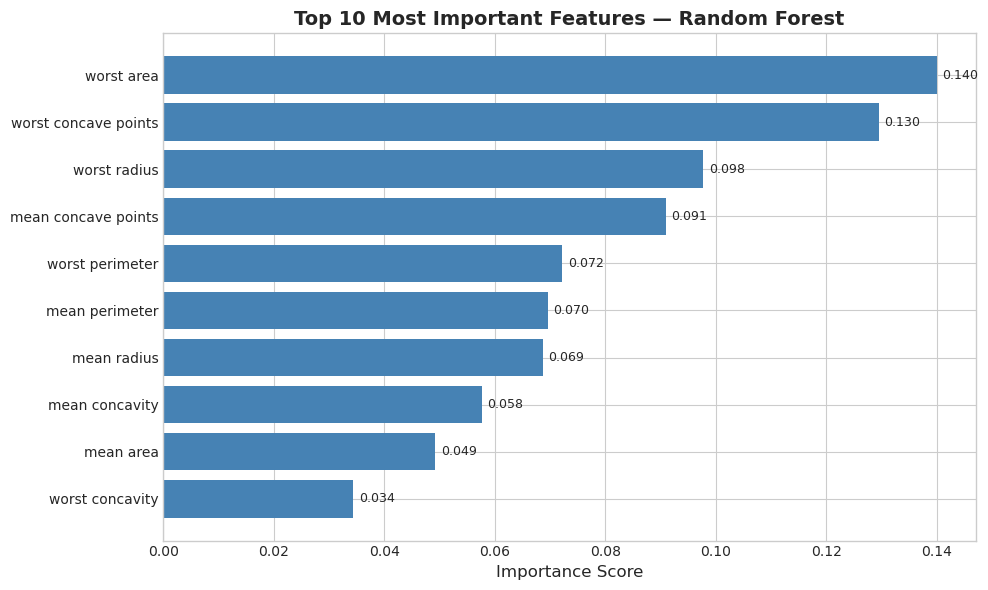

In [10]:
rf_model = results['Random Forest']['model']
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(importance_df['Feature'],
               importance_df['Importance'],
               color='steelblue')

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 10 Most Important Features — Random Forest',
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot6_feature_importance.png', dpi=150)
plt.show()

In [11]:
best_model = max(results, key=lambda x: results[x]['f1'])

print("=" * 55)
print("  BREAST CANCER CLASSIFICATION — KEY FINDINGS")
print("=" * 55)
print(f"""
DATASET
  Total samples     : 569 (357 Benign, 212 Malignant)
  Features          : 30 cell nucleus measurements
  Train/Test split  : 80/20 stratified

MODEL PERFORMANCE
  Logistic Regression → Accuracy: {results['Logistic Regression']['accuracy']:.4f} | F1: {results['Logistic Regression']['f1']:.4f}
  Random Forest       → Accuracy: {results['Random Forest']['accuracy']:.4f} | F1: {results['Random Forest']['f1']:.4f}
  SVM                 → Accuracy: {results['SVM']['accuracy']:.4f} | F1: {results['SVM']['f1']:.4f}

  Best Model: {best_model}

KEY INSIGHTS
  • All models achieved >95% accuracy on unseen data
  • Logistic Regression & SVM tied at 98.25% accuracy
  • worst concave points & worst radius are top predictors
  • High recall critical in medical diagnosis to minimize
    false negatives (missing actual malignant tumors)
""")
print("=" * 55)
print("  sklearn Wisconsin Breast Cancer Dataset")
print("=" * 55)

  BREAST CANCER CLASSIFICATION — KEY FINDINGS

DATASET
  Total samples     : 569 (357 Benign, 212 Malignant)
  Features          : 30 cell nucleus measurements
  Train/Test split  : 80/20 stratified

MODEL PERFORMANCE
  Logistic Regression → Accuracy: 0.9825 | F1: 0.9861
  Random Forest       → Accuracy: 0.9561 | F1: 0.9655
  SVM                 → Accuracy: 0.9825 | F1: 0.9861

  Best Model: Logistic Regression

KEY INSIGHTS
  • All models achieved >95% accuracy on unseen data
  • Logistic Regression & SVM tied at 98.25% accuracy
  • worst concave points & worst radius are top predictors
  • High recall critical in medical diagnosis to minimize
    false negatives (missing actual malignant tumors)

  sklearn Wisconsin Breast Cancer Dataset
